In [1]:
import numpy as np
import torch
from torch.distributions import HalfNormal, Uniform, Normal
from scipy import stats
from sbi.utils import BoxUniform, MultipleIndependent, mcmc_transform
from sbi.neural_nets import posterior_nn, likelihood_nn
import scipy
from sbi.inference import NPE, MCMCPosterior, posterior_estimator_based_potential, simulate_for_sbi
from sbi.neural_nets.embedding_nets import FCEmbedding, CNNEmbedding, PermutationInvariantEmbedding, ResNetEmbedding1D
from matplotlib import pyplot as plt
from sbi.analysis import pairplot, plot_summary
import pandas as pd
import corner
from sbi.inference import NLE_A, NRE_A, NRE_B, NRE_C, NPE_C, NPE_A

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define simulator parameters
f_low = 10
f_high = 200
fref  = 25
pi = np.pi
sqrt = np.sqrt
H100 = 3.241e-18
h    = 0.679
H0   = h * H100
T_obs = 365 * 24 * 3600
Delta_f = 1/32.
N_bins = int((f_high - f_low) / Delta_f) + 1
freq = np.linspace(f_low, f_high, N_bins)   
psd = np.genfromtxt("data/cosmic_explorer_40km_for_paper.txt")
psd[0, 0]  = 4.99999999999999999
psd[:, 1] = psd[:, 1]**2
gamma = np.genfromtxt("data/gamma_HL.txt")
# Interpolations
psd_interp = scipy.interpolate.interp1d(psd[:, 0], psd[:, 1], fill_value="extrapolate")
gamma_interp = scipy.interpolate.interp1d(gamma[:, 0], gamma[:, 1], fill_value="extrapolate")
psd_vals = psd_interp(freq)
gamma_vals = gamma_interp(freq)

In [3]:
numerator = (20 * np.pi**2 * freq**3)**2 * psd_vals**2
denominator = (3 * H0**2)**2 * 8 * gamma_vals**2
T = 1 / (freq[1] - freq[0])
N = int(2 * T_obs // T - 1)
sigma = np.sqrt(numerator / denominator / N)

In [4]:
prior = MultipleIndependent( [HalfNormal(torch.tensor([1.0])),  # scaled Ω
#Uniform(torch.tensor([-14.0]), torch.tensor([-10.0])),
        Normal(torch.tensor([0.0]), torch.tensor([1.0]))]
                            ,validate_args=False)

In [65]:
def simulate_physical(theta_scaled):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)

    omega_scaled = theta_scaled[:, 0] # unconstrained N(0,1)
    alpha        = theta_scaled[:, 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref[:, None] 
    alpha_term = torch.tensor(freq / fref)[None, :] ** alpha[:, None]

    # True model
    C_true = Omega_ref * alpha_term

    # Add noise (Gaussian)
    rng = np.random.default_rng()
    C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)

    # compute optimal summaries
   # summaries = optimal_summaries(C_noisy, sigma, freq, gamma_vals, alpha)

    return torch.tensor(C_noisy, dtype=torch.float32)
    
def simulate_multi(theta_scaled, M=10):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)
    omega_scaled =  theta_scaled[0]  # unconstrained N(0,1)
    alpha        = theta_scaled[ 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref
    alpha_term = torch.tensor(freq / fref)** alpha

    # True model
    C_true = Omega_ref * alpha_term

    # Add noise (Gaussian)
    rng = np.random.default_rng()
    C_noisy = C_true +  rng.normal(0, sigma, size=(M,len(freq)))
    # compute optimal summaries
   # summaries = optimal_summaries(C_noisy, sigma, freq, gamma_vals, alpha)

    return torch.tensor(C_noisy, dtype=torch.float32)
    #C_noisy = np.maximum(C_noisy, 0.0)
    
def simulate_multi_no_noise(theta_scaled, M=10):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)
    omega_scaled =  theta_scaled[0]  # unconstrained N(0,1)
    alpha        = theta_scaled[ 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref
    alpha_term = torch.tensor(freq / fref)** alpha

    # True model
    C_true = Omega_ref * alpha_term

    # Add noise (Gaussian)
   # rng = np.random.default_rng()
    #C_noisy = C_true +  rng.normal(0, sigma, size=(M,len(freq)))
    # compute optimal summaries
   # summaries = optimal_summaries(C_noisy, sigma, freq, gamma_vals, alpha)

    return torch.tensor(C_true, dtype=torch.float32)
    #C_noisy = np.maximum(C_noisy, 0.0)
    
def simulator_no_noise(theta_scaled):
    """
    Generate noisy power spectra given physical parameters.
    This is the *true* generative model used to train SBI.
    """
    #theta_scaled = torch.as_tensor(theta_scaled, dtype=torch.float32)

    omega_scaled = theta_scaled[:, 0] # unconstrained N(0,17
    alpha        = theta_scaled[:, 1]    # unconstrained
    Omega_ref = 1e-11*(omega_scaled) 
    Omega_ref =Omega_ref[:, None]
    alpha_term = torch.tensor(freq / fref)[None, :] ** alpha[:, None]

    # True model
    C_true = Omega_ref * alpha_term

    return torch.tensor(C_true, dtype=torch.float32)

logf = torch.log10(freq)

def compute_stats(C_noisy):
    C_whitened = C_noisy/sigma
    amp_stat = torch.mean([C_whitened, dim=1, keepdim=True)
    slope_stat = torch.sum(C_whitened * logf, dim=1, keepdim=True)
    x_input = torch.cat([C_whitened, amp_stat, slope_stat], dim=1)
    return x_input
    

simulate multiple noisy realizations per theta

In [6]:
def compute_summaries(freq, x): 
    x =  torch.tensor(x, dtype = torch.float32)
    freq = torch.tensor(freq, dtype = torch.float32)
    logf = torch.log(freq)

    
    t1 = x.mean(dim=1)

    t2 = ((x - x.mean(dim=1, keepdim=True)) * logf).mean(dim=1)
    
    x_summary = torch.stack([t1, t2], dim=1)
    return x_summary

In [7]:
import torch

def optimal_summaries(C_f, sigma, f, gamma, alpha):
    """
    Compute optimal stochastic background summaries.

    Parameters
    ----------
    C_f : tensor (batch, D)
        Cross-correlation spectrum
    sigma : tensor (D)
        Noise std per frequency bin
    f : tensor (D)
        Frequencies
    gamma : tensor (D)
        Overlap reduction function
    alpha : tensor (batch,) or float
        Spectral index

    Returns
    -------
    summaries : tensor (batch, 2)
        Optimal compression statistics
    """
    gamma = torch.tensor(gamma)
    f = torch.tensor(f)
    # ensure broadcast
    if isinstance(alpha, float) or len(torch.tensor(alpha).shape) == 0:
        alpha = torch.tensor(alpha).expand(C_f.shape[0])

    # expected spectral shape (without Ω amplitude)
    s_shape = gamma * f**alpha[:, None]

    inv_var = 1.0 / sigma**2

    # optimal weights
    w = s_shape * inv_var

    # summaries
    t1 = torch.sum(C_f * w, dim=1)
    t2 = torch.sum(s_shape * w, dim=1)

    return torch.stack([t1, t2], dim=1)

In [8]:
import torch
import torch.nn as nn

class SpectrumEmbedding(nn.Module):

    def __init__(self, frequencies):
        super().__init__()

        self.register_buffer("logf", torch.log10(frequencies))

        D = len(frequencies)

        self.net = nn.Sequential(
            nn.Linear(2 * D, 4076),
            nn.ReLU(),
            nn.Linear(4076, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 8)
        )

    def forward(self, x):

        batch_size = x.shape[0]

        logf = self.logf.unsqueeze(0).repeat(batch_size, 1)
        

        x_aug = torch.cat([x, logf], dim=1)

        return self.net(x_aug)

In [9]:
# Simulate observation
theta_true = torch.tensor([[1,  0]])     # shape (1, 2)
x_obs= simulate_physical(theta_true)          # shape (1, Nfreq)

#x_obs=torch.tensor(x_obs/sigma, dtype= torch.float32)
#x_obs = optimal_summaries(x_obs, sigma, gamma_vals, freq, 0.0)
#x_obs = torch.sign(x_obs) * torch.log10(1 + torch.abs(x_obs))
#x_obs = compute_summaries(freq, x_obs)

# Ensure correct shape: leading batch dimension = 1
print(x_obs.shape)  # (1, Nfreq)

torch.Size([1, 6081])


/local/lexi.leali/ipykernel_777927/1236360374.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_777927/1236360374.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)


In [10]:
np.mean(sigma)

np.float64(7.374600089685928e-08)

In [11]:
from sbi.neural_nets import classifier_nn
neural_net = classifier_nn(
    model="mlp",
    #embedding_net_x=embedding_net,
   # hidden_features=128,
    #num_blocks=3
)

In [12]:


#embedding_net = SpectrumEmbedding(torch.tensor(freq, dtype = torch.float32))


In [13]:
# Use the same training data 
M = 10#number of noise realizations for each theta
theta = prior.sample((1000,))

x_all = []
theta_all = []

for theta_i in theta:

    x_multi = simulate_multi(theta_i, M)
    theta_rep = theta_i.repeat(M,1)

    x_all.append(x_multi)
    theta_all.append(theta_rep)

x_train = torch.vstack(x_all)
theta_all = torch.vstack(theta_all)

#x_train= torch.tensor(x_train / sigma, dtype=torch.float32)
#x_train = torch.sign(x_train) * torch.log10(1 + torch.abs(x_train))
#x_train = compute_summaries(freq, x_train)

/local/lexi.leali/ipykernel_777927/1236360374.py:43: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true +  rng.normal(0, sigma, size=(M,len(freq)))
/local/lexi.leali/ipykernel_777927/1236360374.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)


## ABC

In [14]:
from sbi.inference import MCABC

In [15]:
ABC_inference = MCABC(simulator = simulate_physical, prior = prior
                     )

In [16]:
ABC_samples = ABC_inference(
    x_obs,
    num_simulations=10000,
    eps=5e-5
)

Running 10000 simulations.:   0%|                     | 0/10000 [00:00<?, ?it/s]/local/lexi.leali/ipykernel_777927/1236360374.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_777927/1236360374.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)
Running 10000 simulations.: 100%|███████| 10000/10000 [00:07<00:00, 1349.84it/s]


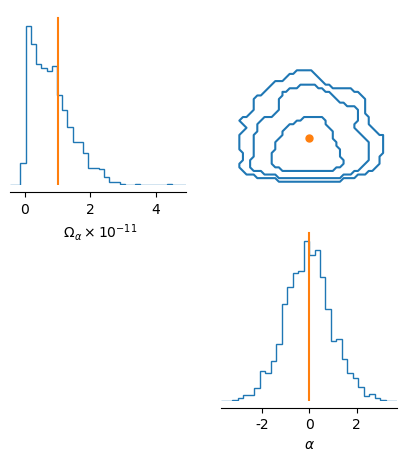

In [17]:
from sbi.analysis import pairplot

_ = pairplot(
    ABC_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r" $\Omega_{\alpha}\times 10^{-11} $", r"$\alpha$"])

## NPE

### NPE-A

In [18]:
proposal_A =  MultipleIndependent( [#HalfNormal(torch.tensor([1e-11])),  # scaled Ω
Normal(torch.tensor([-12.0]), torch.tensor([(4/3)**0.5])),
        Normal(torch.tensor([0.0]), torch.tensor([1.0]))]
                            ,validate_args=False)

In [19]:
NPEA_inference = NPE_A(prior)#, density_estimator=neural_posterior)
Apost_density_estimator= NPEA_inference.append_simulations(theta_all, x_train, proposal = prior).train(validation_fraction = 0.2, 
                                                                                                      #learning_rate = 1e-5
                                                                                                       )

 Training neural network. Epochs trained: 19


KeyboardInterrupt



In [ ]:
NPEA_posterior = NPEA_inference.build_posterior(Apost_density_estimator)

In [ ]:
NPEA_posterior = NPEA_posterior.set_default_x(x_obs)
# 7. Sample from posterior
NPEA_samples = NPEA_posterior.sample((1_000,))  # draws from p(theta | x_obs)
print(NPEA_samples.shape)  # (2000, 2)

In [ ]:
from sbi.analysis import plot_summary
# plot training loss
_ = plot_summary(NPEA_inference, tags=["training_loss", "valida

In [ ]:
from sbi.analysis import pairplot

_ = pairplot(
    NPEA_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r"log10 $\Omega_{\alpha} $", r"$\alpha$"])

### NPE-C

In [25]:
neural_posterior = posterior_nn(model="maf")#, hidden_features = 32)#, embedding_net=embedding_net)
# Setup the inference procedure with NPE
NPEC_inference = NPE_C(prior, density_estimator=neural_posterior)
Cpost_density_estimator = NPEC_inference.append_simulations(theta_all, x_train, proposal = prior).train(validation_fraction = 0.2, 
                                                                                                        learning_rate = 5e-6
                                                                                                       )

 Neural network successfully converged after 117 epochs.

In [26]:
NPEC_posterior = NPEC_inference.build_posterior(Cpost_density_estimator)

In [27]:
NPEC_posterior = NPEC_posterior.set_default_x(x_obs)
# 7. Sample from posterior
NPEC_samples = NPEC_posterior.sample((1_000,))  # draws from p(theta | x_obs)
print(NPEC_samples.shape)  # (2000, 2)

1038it [00:02, 381.21it/s]                                                      

torch.Size([1000, 2])


For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/home/lexi.leali/sbi-logs/NPE_C/2026-03-10T19_09_39.014398' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


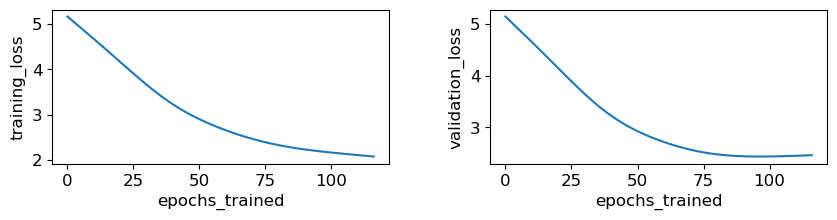

In [28]:
from sbi.analysis import plot_summary
# plot training loss
_ = plot_summary(NPEC_inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
# All training logs are available in `trainer.summary

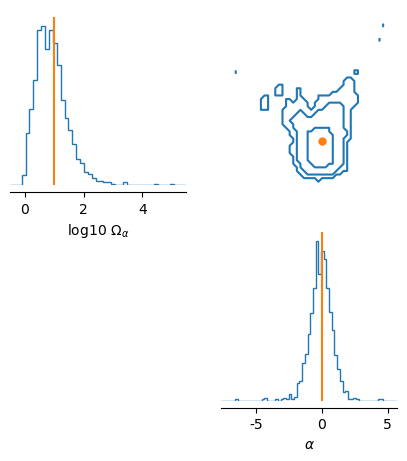

In [29]:
from sbi.analysis import pairplot

_ = pairplot(
    NPEC_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r"log10 $\Omega_{\alpha} $", r"$\alpha$"])

/local/lexi.leali/ipykernel_777927/1236360374.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
/local/lexi.leali/ipykernel_777927/1236360374.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_noisy, dtype=torch.float32)
Sampling 200 times (300,) posterior samples.: 100%|█| 200/200 [06:00<00:00,  1.8
Calculating ranks for 200 SBC samples: 100%|█| 200/200 [00:00<00:00, 12264.76it/


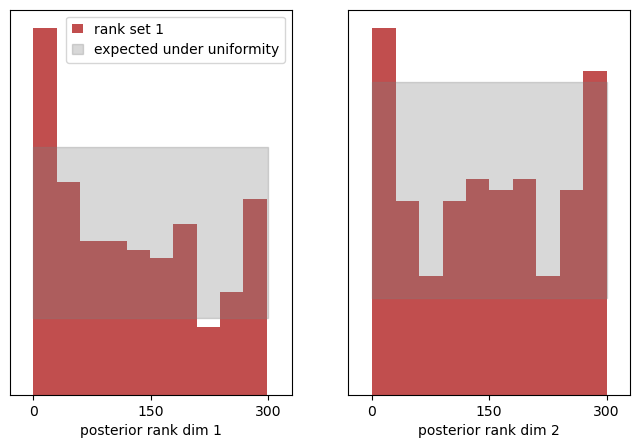

In [30]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

 
NPEC_posterior = NPEC_inference.build_posterior()

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s
prior_samples = prior.sample((num_sbc_samples,))
prior_predictives = simulate_physical(prior_samples)

num_posterior_samples = 300
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    NPEC_posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  # by passing None we use a heuristic for the number of bins.
)

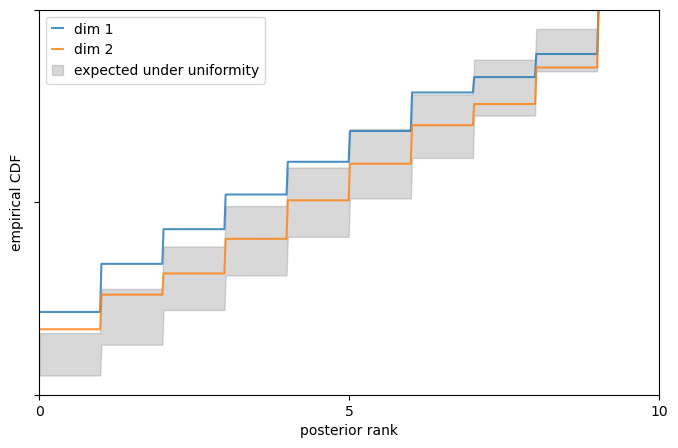

In [31]:
f, ax = sbc_rank_plot(ranks, 1_000, plot_type="cdf")

## NLE

In [32]:
neural_likelihood =likelihood_nn(model="maf", hidden_features = 32)
NLE_inference = NLE_A(prior, density_estimator =neural_likelihood )
likelihood_estimator = NLE_inference.append_simulations(theta_all, x_train).train(validation_fraction = 0.2#, learning_rate = 3e-4
                                                                                 )
NLE_posterior = NLE_inference.build_posterior(likelihood_estimator)

 Neural network successfully converged after 116 epochs.

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


In [33]:
NLE_posterior = NLE_posterior.set_default_x(x_obs)

NLE_samples = NLE_posterior.sample((1_000,))  # draws from p(theta | x_obs)
print(NLE_samples.shape)  # (2000, 2)

Generating 20 MCMC inits via resample strategy: 100%|█| 20/20 [00:28<00:00,  1.4
Running vectorized MCMC with 20 chains: 100%|█| 6000/6000 [00:48<00:00, 124.94it

torch.Size([1000, 2])


For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/home/lexi.leali/sbi-logs/NLE_A/2026-03-10T21_55_51.451130' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epochs_trained', 'training_loss', 'validation_loss'].


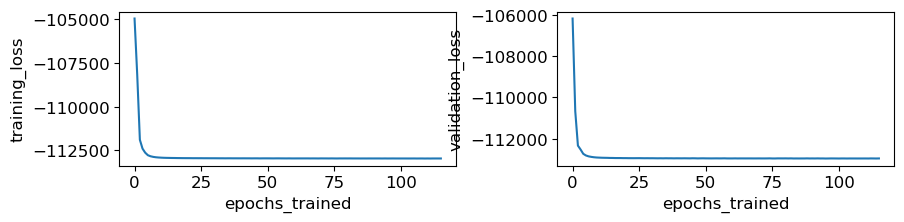

In [34]:
from sbi.analysis import plot_summary
_ = plot_summary(NLE_inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
# All training logs are available in `trainer.summary

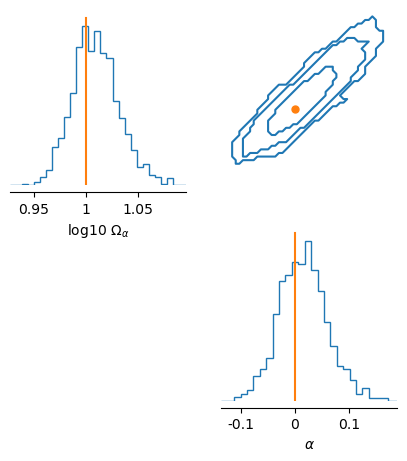

In [35]:

_ = pairplot(
    NLE_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r"log10 $\Omega_{\alpha} $", r"$\alpha$"])

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/sbi/diagnostics/sbc.py:83: UserWarning: Using non-batched sampling. Depending on the number of different xs ( 200) and the number of parallel workers 1, this might take a lot of time.
  posterior_samples = get_posterior_samples_on_batch(
Sampling 200 times (300,) posterior samples.: 100%|█| 200/200 [4:06:33<00:00, 73
Calculating ranks for 200 SBC samples: 100%|█| 200/200 [00:00<00:00, 9193.10it/s


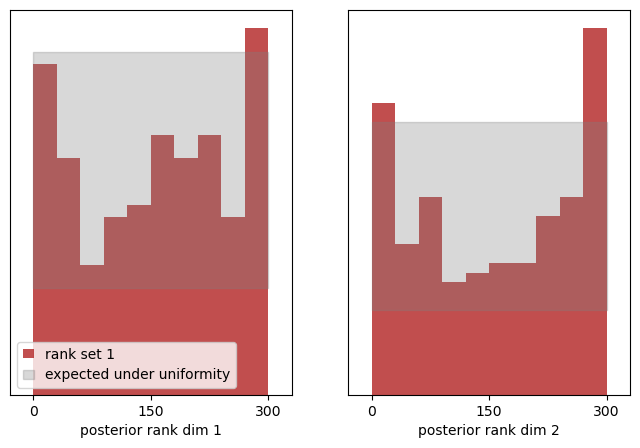

In [36]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot
 
NLE_posterior = NLE_inference.build_posterior()

ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    NLE_posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  # by passing None we use a heuristic for the number of bins.
)

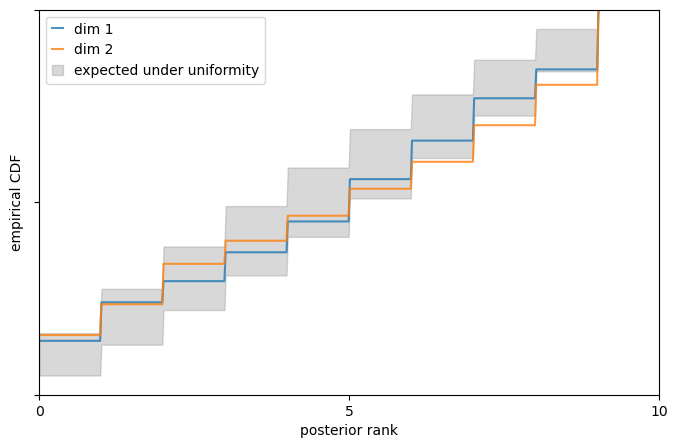

In [37]:
f, ax = sbc_rank_plot(ranks, 1_000, plot_type="cdf")

## NRE

### NRE-A

In [38]:
NREA_inference = NRE_A(prior)
Aratio_estimator = NREA_inference.append_simulations(theta_all, x_train).train(validation_fraction = 0.2, learning_rate = 1e-5
                                                                            )
NREA_posterior = NREA_inference.build_posterior(Aratio_estimator)


 Neural network successfully converged after 88 epochs.

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


In [39]:
NREA_posterior = NREA_posterior.set_default_x(x_obs)
# 7. Sample from posterior
NREA_samples = NREA_posterior.sample((1_000,))  # draws from p(theta | x_obs)
print(NREA_samples.shape)  # (2000, 2)

Generating 20 MCMC inits via resample strategy: 100%|█| 20/20 [00:02<00:00,  8.2
Running vectorized MCMC with 20 chains: 100%|█| 6000/6000 [00:09<00:00, 655.01it

torch.Size([1000, 2])


For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/home/lexi.leali/sbi-logs/NRE_A/2026-03-11T03_36_47.544287' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epochs_trained', 'training_loss', 'validation_loss'].


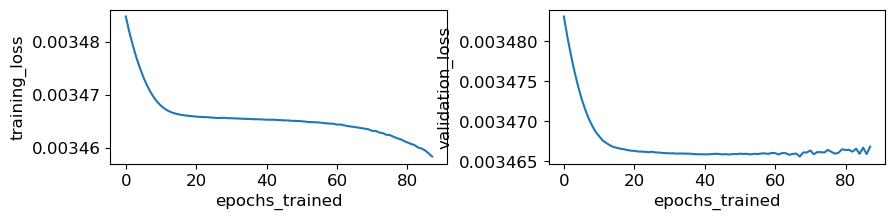

In [40]:
from sbi.analysis import plot_summary
# plot training loss
_ = plot_summary(NREA_inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
# All training logs are available in `trainer.summary

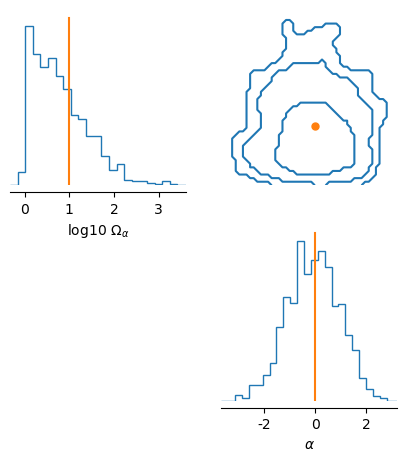

In [41]:

_ = pairplot(
    NREA_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r"log10 $\Omega_{\alpha} $", r"$\alpha$"])

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/sbi/diagnostics/sbc.py:83: UserWarning: Using non-batched sampling. Depending on the number of different xs ( 200) and the number of parallel workers 1, this might take a lot of time.
  posterior_samples = get_posterior_samples_on_batch(
Sampling 200 times (300,) posterior samples.: 100%|█| 200/200 [1:05:33<00:00, 19
Calculating ranks for 200 SBC samples: 100%|█| 200/200 [00:00<00:00, 14133.89it/


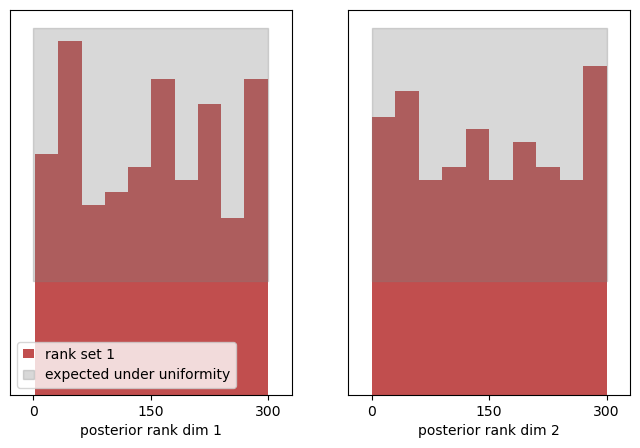

In [42]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot
 
NREA_posterior = NREA_inference.build_posterior()
#prior_samplesA = proposal_A.sample((num_sbc_samples,))
#prior_predictivesA= simulate_physical(prior_samplesA)
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    NREA_posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  # by passing None we use a heuristic for the number of bins.
)

### NRE-B

In [43]:
NREB_inference = NRE_B(prior)
Bratio_estimator = NREB_inference.append_simulations(theta_all, x_train).train(validation_fraction = 0.2, 
                                                                               learning_rate = 5e-7
                                                                            )
NREB_posterior = NREB_inference.build_posterior(Bratio_estimator)


 Neural network successfully converged after 33 epochs.

In [44]:
NREB_posterior = NREB_posterior.set_default_x(x_obs)
# 7. Sample from posterior
NREB_samples = NREB_posterior.sample((1_000,))  # draws from p(theta | x_obs)
print(NREB_samples.shape)  # (2000, 2)

Generating 20 MCMC inits via resample strategy: 100%|█| 20/20 [00:03<00:00,  5.1
Running vectorized MCMC with 20 chains: 100%|█| 6000/6000 [00:06<00:00, 958.21it

torch.Size([1000, 2])


For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/home/lexi.leali/sbi-logs/NRE_B/2026-03-11T04_43_32.046236' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epochs_trained', 'training_loss', 'validation_loss'].


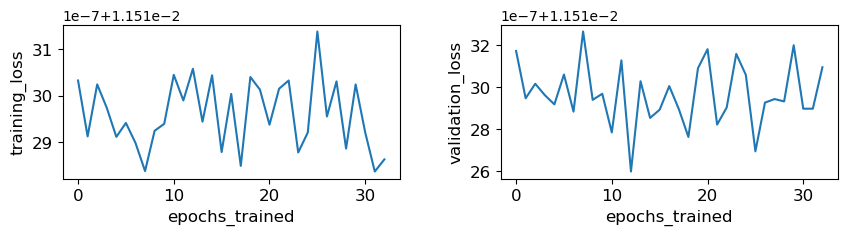

In [45]:
from sbi.analysis import plot_summary
# plot training loss
_ = plot_summary(NREB_inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
# All training logs are available in `trainer.summary

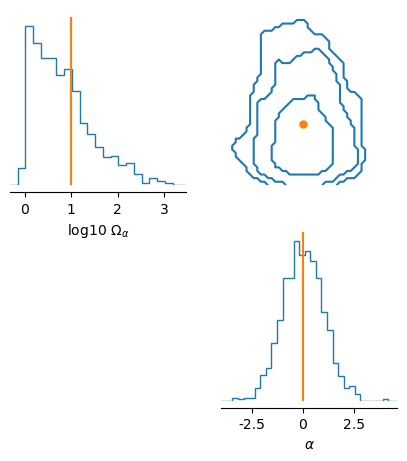

In [46]:
_ = pairplot(
    NREB_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r"log10 $\Omega_{\alpha} $", r"$\alpha$"])

Sampling 200 times (300,) posterior samples.: 100%|█| 200/200 [25:07<00:00,  7.5
Calculating ranks for 200 SBC samples: 100%|█| 200/200 [00:00<00:00, 13533.29it/


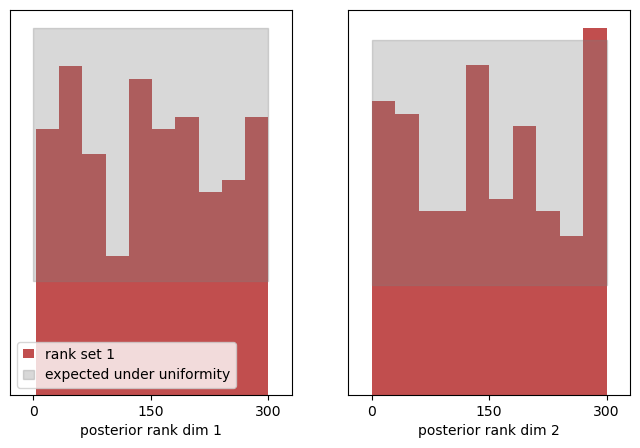

In [47]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot
 
NREB_posterior = NREB_inference.build_posterior()

ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    NREB_posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  # by passing None we use a heuristic for the number of bins.
)

### NRE-C

In [48]:
NREC_inference = NRE_C(prior)
Cratio_estimator = NREC_inference.append_simulations(theta_all, x_train).train(validation_fraction = 0.2, learning_rate = 1e-5
                                                                            )
NREC_posterior = NREC_inference.build_posterior(Cratio_estimator)


 Neural network successfully converged after 83 epochs.

In [52]:
NREC_posterior = NREC_posterior.set_default_x(x_obs)
# 7. Sample from posterior
NREC_samples = NREC_posterior.sample((1_000,))  # draws from p(theta | x_obs)
print(NREC_samples.shape)  # (2000, 2)

Generating 20 MCMC inits via resample strategy: 100%|█| 20/20 [00:10<00:00,  1.9
Running vectorized MCMC with 20 chains: 100%|█| 6000/6000 [06:56<00:00, 14.42it/

torch.Size([1000, 2])


For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/home/lexi.leali/sbi-logs/NRE_C/2026-03-11T05_10_06.889418' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epochs_trained', 'training_loss', 'validation_loss'].


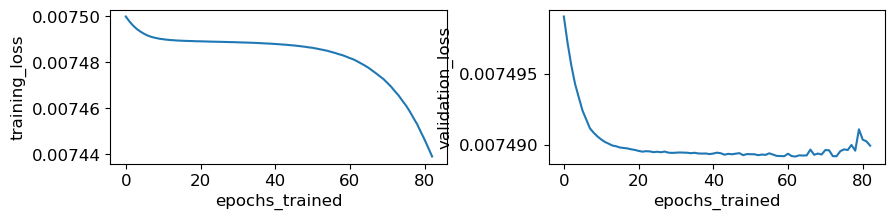

In [53]:
from sbi.analysis import plot_summary
# plot training loss
_ = plot_summary(NREC_inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
# All training logs are available in `trainer.summary

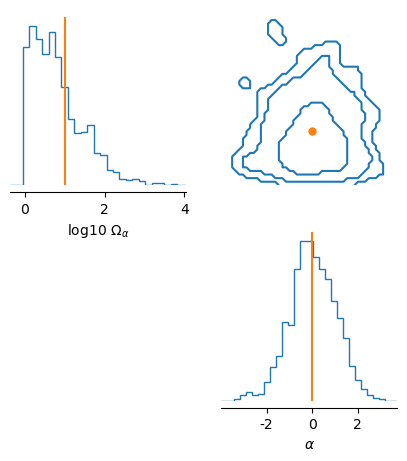

In [54]:

_ = pairplot(
    NREC_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r"log10 $\Omega_{\alpha} $", r"$\alpha$"])

In [55]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot
 
NREC_posterior = NREC_inference.build_posterior()

ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    NREC_posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=num_posterior_samples,
    plot_type="hist",
    num_bins=None,  # by passing None we use a heuristic for the number of bins.
)

Sampling 200 times (300,) posterior samples.:   0%| | 1/200 [08:10<27:08:12, 490

KeyboardInterrupt



In [ ]:
from sbi.analysis.plot import sbc_rank_plot
from sbi.diagnostics import check_sbc, check_tarp, run_sbc, run_tarp
check_stats = check_sbc(
    ranks, prior_samples, dap_samples, num_posterior_samples=num_posterior_samples
)

In [ ]:
f, ax = sbc_rank_plot(ranks, 1_000, plot_type="cdf")

In [103]:
# import numpy as np
import torch
from torch.distributions import HalfNormal, Uniform, Normal
from scipy.special import logsumexp

# ------------------------------
# 1. Define grids (physical)
# ------------------------------
Omega_vals = np.linspace(0, 3, 1_000)   # physical Ω grid
alpha_vals = np.linspace(-3, 3, 1_000)             # α grid

M = len(Omega_vals)
K = len(alpha_vals)

# ------------------------------
# 2. Convert to simulator space
# ------------------------------
Omega_scaled = Omega_vals         
# Make full (M,K,2) grid of parameters in simulator units
Omega_mesh, alpha_mesh = np.meshgrid(Omega_scaled, alpha_vals, indexing="ij")
theta_grid = np.stack([Omega_mesh, alpha_mesh], axis=-1).reshape(-1, 2)

theta_torch = torch.tensor(theta_grid, dtype=torch.float32)
N = theta_torch.shape[0]

#mask = x_obs < 0
#x_obs[mask] = np.nan
# ------------------------------
# 3. Define priors
# ------------------------------
prior_alpha = Normal(loc =torch.tensor(0.0, dtype=torch.float32), scale=torch.tensor(1.0, dtype=torch.float32))
prior_Omega = HalfNormal(
                      torch.tensor(1.0, dtype=torch.float32))



In [104]:
# ------------------------------
# 4. Loop over grid in batches
# ------------------------------
batch_size = 5000
logpost_list = []

for i in range(0, N, batch_size):
    #print(i)
    batch = theta_torch[i:i+batch_size]

    # Simulator output: must be NO-NOISE
    out = simulator_no_noise(batch)
    # x_obs: observed clipped data shape (D,) or (B, D) if multiple obs

    logL = -0.5 * torch.sum(((x_obs - out) / sigma)**2, dim=1)

    # Prior in SIMULATOR SPACE (very important!)
    logP = prior_Omega.log_prob(batch[:,0]) + prior_alpha.log_prob(batch[:,1])
   # print(prior_Omega.log_prob(batch[:,0]))
    # Posterior
    logpost_list.append((logL+logP).cpu().numpy())

# Flatten → reshape to (M,K)
logpost_flat = np.concatenate(logpost_list, axis=0)
logpost_grid = logpost_flat.reshape(M, K)

# ------------------------------
# 5. Normalize posterior
# ------------------------------
logZ = logsumexp(logpost_grid.ravel())
logpost_norm = logpost_grid - logZ
post = np.exp(logpost_norm)



/local/lexi.leali/ipykernel_777927/416138087.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(C_true, dtype=torch.float32)
/local/lexi.leali/ipykernel_777927/2554859257.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  logL = -0.5 * torch.sum(((x_obs - out) / sigma)**2, dim=1)


In [105]:
post_omega = np.sum(post, axis=1)   # (M,)
post_alpha = np.sum(post, axis=0)   # (K,)

# ------------------------------
# 7. Means + 68% credible intervals
# ------------------------------
def credible_interval(vals, pdf, frac=0.68):
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]
    lo = np.searchsorted(cdf, (1-frac)/2)
    hi = np.searchsorted(cdf, 1-(1-frac)/2)
    return vals[lo], vals[hi]

omega_mean = (Omega_vals * post_omega).sum()
alpha_mean = (alpha_vals * post_alpha).sum()

omega_lo, omega_hi = credible_interval(Omega_vals, post_omega)
alpha_lo, alpha_hi = credible_interval(alpha_vals, post_alpha)

print("Omega mean (physical)   :", omega_mean)
print("Omega 68% CI (physical) :", (omega_lo, omega_hi))
print("Alpha mean              :", alpha_mean)
print("Alpha 68% CI            :", (alpha_lo, alpha_hi))

Omega mean (physical)   : 1.0099570337853492
Omega 68% CI (physical) : (np.float64(0.9879879879879879), np.float64(1.03003003003003))
Alpha mean              : 0.02654288982025136
Alpha 68% CI            : (np.float64(-0.009009009009008917), np.float64(0.06306306306306286))


In [106]:

posterior_grid = post.reshape(len(Omega_vals), len(alpha_vals))

# --- sanity check ---
print("Sum over grid (should be ≈1):", np.sum(posterior_grid))
print("Posterior min/max:", np.min(posterior_grid), np.max(posterior_grid))
# --- sample from posterior grid ---
num_samples = 2000


Sum over grid (should be ≈1): 1.0000000000000404
Posterior min/max: 0.0 0.007685238183202832


In [107]:
weights = posterior_grid.flatten()
idx = np.random.choice(len(weights), size=num_samples, p=weights/weights.sum())

A, O = np.meshgrid(alpha_vals, Omega_vals)
samples_grid = np.column_stack((O.flatten()[idx], A.flatten()[idx]))  # (Ω, α)
# --- make DataFrame for plotting ---
df_grid = pd.DataFrame(samples_grid, columns=["Omega", "alpha"])
df_grid["source"] = "Grid"

In [108]:
df_NLE = pd.DataFrame(NLE_samples, columns=["Omega", "alpha"])
df_NLE["source"] = "NLE"

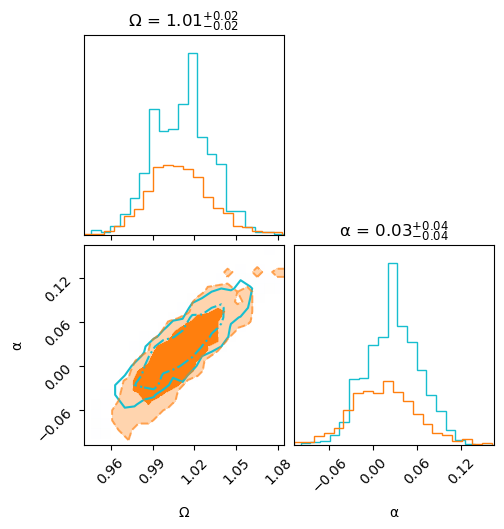

In [109]:
# ----------------------------
# Corner plot
# ----------------------------
figure = corner.corner(
    df_grid[["Omega", "alpha"]].values,
    labels=["Ω", "α"],
    color="C9",  # default color; we'll overlay SBI manually
    show_titles=True,
    title_kwargs={"fontsize": 12},
    #truths=theta_true[0],
    truth_color="red",
    #range=([0.945, 2.5e-11], [0,3]),
    plot_datapoints=False,
    fill_contours=False,
    contour_kwargs={"alpha":1, "colors":["C9"],"linestyles": ["-", "-."]},
    levels=(0.68, 0.95)#, 0.997
         # 
)
# Overlay SBI posterior samples in a different color
corner.corner(
    df_NLE[["Omega", "alpha"]].values,
    fig=figure,
    color="C1",
    plot_datapoints=False,
    fill_contours=True,
    #range=([0, 2.5e-11], [0,3]),
    contour_kwargs={"alpha":0.6, "colors":["C1"], "linestyles": ["--", "-."]},
    hist_kwargs={
    "histtype": "step",
    "linestyle": "-",       # dash-dot for SBI 1D marginal
    "color": "C1",
    "linewidth": 1
    },
    levels=(0.68, 0.95), 
            #0.997
          # ),
)

plt.show()